In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0' # disaable Intel-obtamized library oneDNN
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # set the loggin level to errors only

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
(X_train, _), (X_test, _) = mnist.load_data()
print(f"X_train before normalization: {X_train}")
# normalize the pixel values
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.
print(f"X_train after normalization: {X_train}")

# adding additional dimension to match keras requirements
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
print(f"X_train after adding additional dimention: {X_train.shape}")

# adding noise to the data
noise_factor = 0.5
X_train_noise = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noise = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)
print(f"X_train_noise before clipping {X_train_noise}")
# clip the values to be between 0 and 1
X_train_noise = np.clip(X_train_noise, 0., 1.)
X_test_noise = np.clip(X_test_noise, 0., 1.)
print(f"X_train_noise after clipping {X_train_noise}")

X_train before normalization: [[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]
X_train after normalization: [[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[

In [10]:
input_layer = Input(shape=(28, 28, 1))
X = Conv2D(16, (3, 3), activation='relu', padding='same')(input_layer)
X = Conv2D(32, (3, 3), activation='relu', padding='same')(X)
X = Flatten()(X)
X = Dense(64, activation='relu')(X)
X = Dense(28*28*32, activation='relu')(X)
X = Reshape((28, 28, 32))(X)
X = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(X)
X = Conv2DTranspose(16, (3, 3), activation='relu', padding='same')(X)
output_layer = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(X)
diffusion_model = Model(input_layer, output_layer)

diffusion_model.compile(optimizer='adam', loss='mean_squared_error')

diffusion_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25088)          │     1,630,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 16)     │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,255,233 (12.42 MB)

 Trainable params: 3,255,233 (12.42 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_noise, X_train))
train_dataset = train_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_test_noise, X_test))
val_dataset = val_dataset.cache().batch(64).prefetch(tf.data.AUTOTUNE)

In [14]:
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

diffusion_model.fit(
    train_dataset,
    epochs=3,
    shuffle=True,
    validation_data=val_dataset,
    callbacks=[early_stopping]
)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 102s 109ms/step - loss: 0.0204 - val_loss: 0.0208
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 103s 110ms/step - loss: 0.0189 - val_loss: 0.0203
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 106s 113ms/step - loss: 0.0180 - val_loss: 0.0203


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


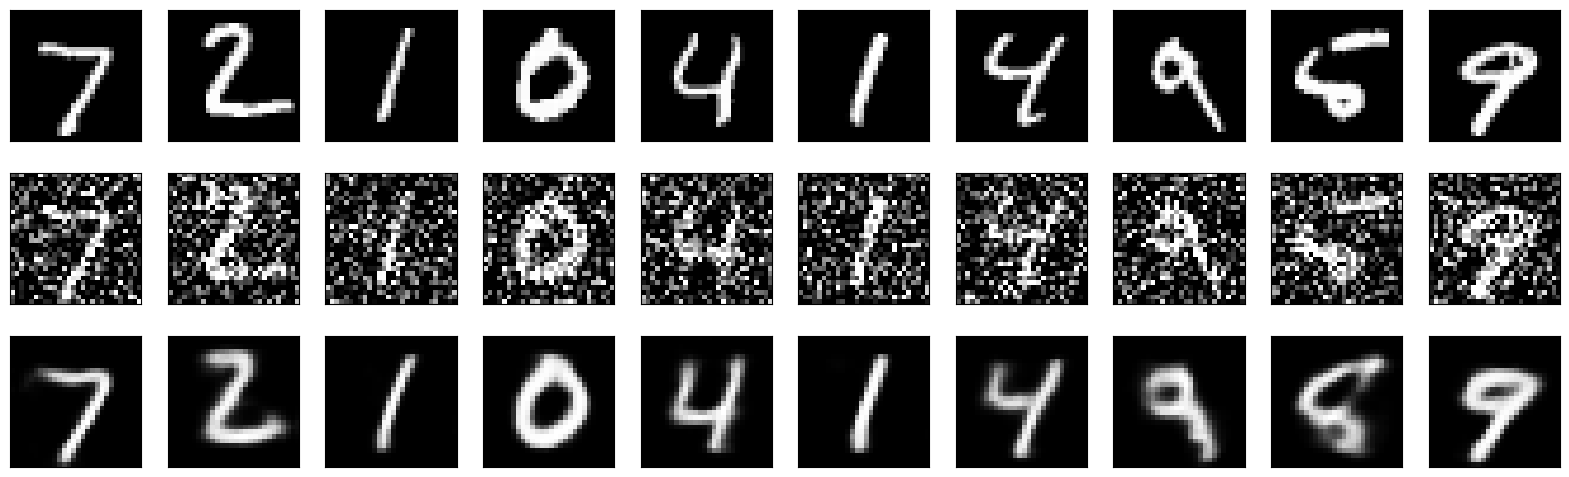

In [15]:
import matplotlib.pyplot as plt

denoised_images = diffusion_model.predict(X_test_noise)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noise[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [18]:
for layer in diffusion_model.layers:
    layer.trainable = False

for i, layer in enumerate(diffusion_model.layers):
    print(f"Layer {i}: {layer.name} - Trainable: {layer.trainable}")

Layer 0: input_layer_1 - Trainable: False
Layer 1: conv2d_3 - Trainable: False
Layer 2: conv2d_4 - Trainable: False
Layer 3: flatten_1 - Trainable: False
Layer 4: dense_2 - Trainable: False
Layer 5: dense_3 - Trainable: False
Layer 6: reshape_1 - Trainable: False
Layer 7: conv2d_transpose_2 - Trainable: False
Layer 8: conv2d_transpose_3 - Trainable: False
Layer 9: conv2d_5 - Trainable: False


In [19]:
for layer in diffusion_model.layers[-4:]:
    layer.trainable = True
for i, layer in enumerate(diffusion_model.layers):
    print(f"Layer {i}: {layer.name} - Trainable: {layer.trainable}")

Layer 0: input_layer_1 - Trainable: False
Layer 1: conv2d_3 - Trainable: False
Layer 2: conv2d_4 - Trainable: False
Layer 3: flatten_1 - Trainable: False
Layer 4: dense_2 - Trainable: False
Layer 5: dense_3 - Trainable: False
Layer 6: reshape_1 - Trainable: True
Layer 7: conv2d_transpose_2 - Trainable: True
Layer 8: conv2d_transpose_3 - Trainable: True
Layer 9: conv2d_5 - Trainable: True


In [20]:
diffusion_model.compile(optimizer='adam', loss='binary_crossentropy')

diffusion_model.fit(
    X_train_noise, X_train,
    epochs=10,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test_noise, X_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 63ms/step - loss: 0.1157 - val_loss: 0.1166
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - loss: 0.1143 - val_loss: 0.1163
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - loss: 0.1138 - val_loss: 0.1162
Epoch 4/10
460/938 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - loss: 0.1139

KeyboardInterrupt: 